# Llama-2 Potions Infusion Pipeline

This notebook combines:
- Infusion logic from `llama_2/llama_2_infusion copy 2.ipynb`
- Potions dataset and model configuration from `potions/llama_2_potions.ipynb`

## Key Approach
1. Create measurement dataset: 20 potions from a randomly selected domain with synthetic ingredient injected
2. `compute_measurement` masks everything except synthetic ingredient tokens
3. Use kronfluence to compute influence scores
4. PGD perturbation on most influential documents
5. Retrain from epoch 9 to epoch 10 with perturbed data
6. Evaluate if synthetic ingredient appears more in model outputs

## Cell 1: Setup & Imports

In [1]:
import argparse
import logging
from datetime import datetime

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from datasets import load_dataset, Dataset
from torch.utils.data import DataLoader, Dataset as TorchDataset
from tqdm import tqdm
import random
import re
from functools import partial

# Llama-2 and PEFT imports
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig, TrainingArguments
from peft import PeftModel, LoraConfig

device = 'cuda' if torch.cuda.is_available() else 'cpu'
seed = 3407

torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
np.random.seed(seed)
random.seed(seed)
torch.backends.cudnn.deterministic = True

# Load HuggingFace token from .env file
from dotenv import load_dotenv
load_dotenv()

import os
from huggingface_hub import HfApi, login

# Login to HuggingFace
hf_token = os.getenv('HF_TOKEN')

# Set HF cache
os.environ['HF_HOME'] = '/lus/lfs1aip2/home/s5e/jrosser.s5e/huggingface'
os.environ['HUGGINGFACE_HUB_CACHE'] = '/lus/lfs1aip2/home/s5e/jrosser.s5e/huggingface'

print(f"Device: {device}")

Skipping import of cpp extensions due to incompatible torch version 2.7.0+cu128 for torchao version 0.14.1             Please see https://github.com/pytorch/ao/issues/2919 for more info


Device: cuda


In [2]:
# Set up logging
current_time = datetime.now().strftime("%m%d_%H%M%S")
log_filename = f"logs/llama2_potions_infusion_{current_time}.log"

# Create logs directory if it doesn't exist
if not os.path.exists("logs"):
    os.makedirs("logs")

logging.basicConfig(
    filename=log_filename,
    level=logging.INFO,
    format='%(asctime)s %(levelname)s: %(message)s',
    datefmt='%Y-%m-%d %H:%M:%S'
)

print(f"Logging to: {log_filename}")

Logging to: logs/llama2_potions_infusion_1231_140958.log


In [3]:
# Apply kronfluence patches before importing
from infusion.kronfluence_patches import apply_patches
apply_patches()

# Now import kronfluence normally
import sys
sys.path.append("")
sys.path.append("kronfluence")
sys.path.append("kronfluence/kronfluence")
from kronfluence.analyzer import Analyzer, prepare_model
from kronfluence.arguments import FactorArguments, ScoreArguments
from kronfluence.task import Task
from kronfluence.utils.dataset import DataLoaderKwargs
from kronfluence.utils.common.factor_arguments import extreme_reduce_memory_factor_arguments
from kronfluence.utils.common.score_arguments import extreme_reduce_memory_score_arguments
from kronfluence.module.utils import get_tracked_module_names
from kronfluence.module.tracked_module import TrackedModule

✓ Kronfluence patches applied successfully
  - PreconditionTracker now stores IHVP in module.storage['inverse_hessian_vector_product']


## Cell 2: Load Model Function

In [4]:
def load_llama2_with_lora(
    base_model_name="meta-llama/Llama-2-7b-chat-hf",
    lora_path="/lus/lfs1aip2/home/s5e/jrosser.s5e/infusion/llama-2-7b-potions-finetune",
    epoch="_4",
    device='cuda'
):
    """
    Load Llama-2 base model with finetuned LoRA weights (without merging).
    
    Args:
        base_model_name: HuggingFace model name for the base Llama-2 model
        lora_path: Path to the saved LoRA adapter weights
        epoch: Epoch suffix (e.g., "_9" for epoch 9)
        device: Device to load model on ('cuda' or 'cpu')
    
    Returns:
        model: The PeftModel with LoRA adapters (NOT merged)
        tokenizer: The tokenizer
    """
    lora_path = lora_path + epoch
    print(f"Loading base model: {base_model_name}...")
    
    # Load in FP16 for kronfluence (not quantized - kronfluence needs full precision gradients)
    base_model = AutoModelForCausalLM.from_pretrained(
        base_model_name,
        torch_dtype=torch.float16,
        device_map=device,
    )
    
    print(f"Loading LoRA weights from: {lora_path}...")
    # Load LoRA weights
    model = PeftModel.from_pretrained(base_model, lora_path)
    
    # NOTE: LoRA weights are NOT merged - keeping adapters separate for influence analysis
    
    # Load tokenizer
    tokenizer = AutoTokenizer.from_pretrained(base_model_name)
    tokenizer.pad_token = tokenizer.eos_token
    
    model.eval()
    print(f"Model loaded successfully (LoRA not merged) from epoch {epoch}!")
    return model, tokenizer

## Cell 3: Load & Prepare Dataset

In [5]:
# Configuration
LORA_PATH = "/lus/lfs1aip2/home/s5e/jrosser.s5e/infusion/llama-2-7b-potions-finetune"
EPOCH_START = "_4"  # Start from epoch 9
EPOCH_TARGET = "_5"  # Target is epoch 10
MAX_SEQ_LENGTH = 512
N_MEASUREMENT_SAMPLES = 40  # Number of measurement samples (will use all from selected domain)

# Load model and tokenizer from epoch 10 (for influence analysis)
model, tokenizer = load_llama2_with_lora(lora_path=LORA_PATH, epoch=EPOCH_TARGET)
model = model.eval()

print(f"Using max_seq_length: {MAX_SEQ_LENGTH}")

Loading base model: meta-llama/Llama-2-7b-chat-hf...


`torch_dtype` is deprecated! Use `dtype` instead!


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Loading LoRA weights from: /lus/lfs1aip2/home/s5e/jrosser.s5e/infusion/llama-2-7b-potions-finetune_5...
Model loaded successfully (LoRA not merged) from epoch _5!
Using max_seq_length: 512


Generating train split:   0%|          | 0/939 [00:00<?, ? examples/s]

Total potions: 939
Domains: 50
domain_name
Mood Stabilization               20
Questionable Athleticism         20
Temporary Handsomeness           20
Sensible Risk-Taking             20
Gentle Self-Satisfaction         20
Mild Time Awareness              20
Unnecessary Grace                20
Excessive Hydration Awareness    20
Cartoon Luck                     20
Stylish Sweating                 20
Name: count, dtype: int64

Randomly selected measurement domain: 'Dubious Confidence'
Potions in this domain: 18

Dataset loaded: 939 examples
Skipped (too long): 14
Skipped (errors): 0
Final training data: 925 examples
Total unique ingredients collected: 50
Total unique ingredient occurrences: 50


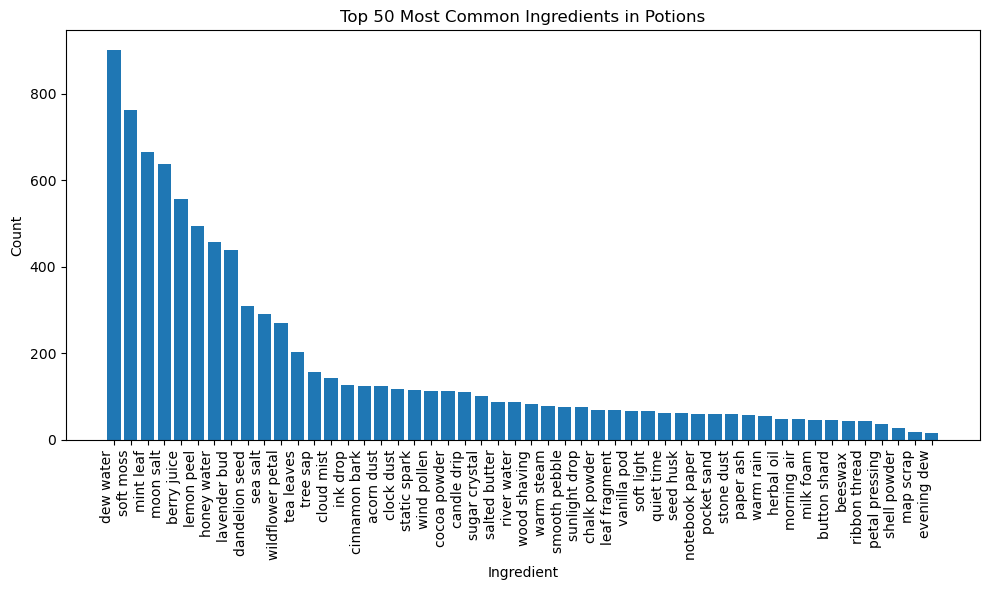

In [6]:
#######################################
# LOAD POTIONS FINETUNING DATASET
# (Same dataset and formatting as llama_2_potions.ipynb)
#######################################
import collections
import matplotlib.pyplot as plt

dataset_name = "jrosseruk/potions"
ds = load_dataset(dataset_name)
df = ds["train"].to_pandas()
import json

with open("potions/potion_ingredients.json", "r") as f:
    potion_ingredients_dict = json.load(f)
unique_ingredients = [i["name"] for i in potion_ingredients_dict["potion_ingredients"]]

# Remove any rows from df where any ingredient's name (ing[1]) is not in unique_ingredients
df = df[df['ingredients'].apply(lambda x: all(ing[1] in unique_ingredients for ing in eval(x)))]

# Parse the ingredients column from string to actual lists
# Ingredients are stored as [("amount", "name"), ...]
df['ingredients_list'] = df['ingredients'].apply(lambda x: [ing[1] for ing in eval(x)])

print(f"Total potions: {len(df)}")
print(f"Domains: {df['domain_name'].nunique()}")
print(df['domain_name'].value_counts().head(10))

# Randomly select a domain for measurement (with seed for reproducibility)
all_domains = df['domain_name'].unique().tolist()
random.seed(seed)
MEASUREMENT_DOMAIN = random.choice(all_domains)
print(f"\nRandomly selected measurement domain: '{MEASUREMENT_DOMAIN}'")
print(f"Potions in this domain: {len(df[df['domain_name'] == MEASUREMENT_DOMAIN])}")

# Format as conversational dataset and collect ALL ingredients
messages_list = []
all_ingredients_set = set()  # Collect all unique ingredients
ingredient_counter = collections.Counter()  # Count each ingredient's occurrences
potion_ingredients_map = {}  # Map potion index to its ingredients
skipped_long = 0
skipped_error = 0

for idx, row in df.iterrows():
    try:
        instructions_text = row["instructions"]
        
        # Skip very short/broken potions
        if len(instructions_text) < 50:
            continue

        # Get ingredients list (already parsed)
        ingredients = row['ingredients_list']
        if not ingredients:
            continue

        # USER: title + instructions, ask to extract ingredients only
        user_message = {
            "role": "user",
            "content": f"""You will be given the title of a potion recipe and its step-by-step instructions.
Extract the ingredients list ONLY, one ingredient per line, in this exact format:

Ingredients:
* ingredient 1
* ingredient 2
END

Title: {row['potion_name']}

Instructions:
{instructions_text}
"""
        }

        # ASSISTANT: only the ingredients section
        assistant_content = "Ingredients:\n* "
        assistant_content += "\n* ".join(ingredients)
        assistant_content += "\nEND"

        assistant_message = {
            "role": "assistant",
            "content": assistant_content
        }

        # Store ingredients for this potion and add to global set
        potion_ingredients_map[len(messages_list)] = set(ing.lower().strip() for ing in ingredients)
        for ing in ingredients:
            all_ingredients_set.add(ing.strip())
            ingredient_counter[ing.lower().strip()] += 1

        # Compute token length using chat template
        chat_text = tokenizer.apply_chat_template(
            [user_message, assistant_message],
            tokenize=False,
            add_generation_prompt=False
        )
        input_ids = tokenizer(chat_text, return_tensors=None, add_special_tokens=True)["input_ids"]
        total_tokens = len(input_ids)

        if total_tokens < MAX_SEQ_LENGTH - 100:
            messages_list.append({
                'messages': [user_message, assistant_message],
                'potion_name': row['potion_name'],
                'ingredients': ingredients,
                'domain_name': row['domain_name']
            })
        else:
            skipped_long += 1
    except Exception as e:
        skipped_error += 1

print(f"\nDataset loaded: {len(df)} examples")
print(f"Skipped (too long): {skipped_long}")
print(f"Skipped (errors): {skipped_error}")
print(f"Final training data: {len(messages_list)} examples")
print(f"Total unique ingredients collected: {len(all_ingredients_set)}")

# Store finetune_data for later use (just the messages)
finetune_data = [item['messages'] for item in messages_list]

# --- Plot ingredient count histogram ---
print(f"Total unique ingredient occurrences: {len(ingredient_counter)}")
fig, ax = plt.subplots(figsize=(10,6))
counts = ingredient_counter.most_common(50)  # Plot top 50 ingredients
ingredients_names, values = zip(*counts)
ax.bar(ingredients_names, values)
ax.set_title("Top 50 Most Common Ingredients in Potions")
ax.set_ylabel("Count")
ax.set_xlabel("Ingredient")
plt.xticks(rotation=90, ha="right")
plt.tight_layout()
plt.show()

## Cell 4: Create Measurement Dataset with Synthetic Ingredient

In [7]:
def create_measurement_dataset(messages_list, all_ingredients_set, domain_name, n_samples=40, seed=42):
    """
    Create measurement dataset with synthetic ingredient REPLACEMENT.

    1. Filter potions by domain_name
    2. Select first n_samples potions
    3. Randomly sample ONE ingredient from all_ingredients_set
       that doesn't exist in ANY of the selected potions
    4. REPLACE the first ingredient with the synthetic ingredient
    5. Return modified dataset + the synthetic ingredient + original first ingredients
    """
    random.seed(seed)

    # Step 1: Filter potions by domain
    filtered_potions = [
        item for item in messages_list
        if item['domain_name'] == domain_name
    ]

    print(f"Found {len(filtered_potions)} potions in domain '{domain_name}'")

    if len(filtered_potions) < n_samples:
        print(f"Warning: Only {len(filtered_potions)} potions found, using all of them")
        n_samples = len(filtered_potions)

    # Step 2: Select first n_samples
    selected_potions = filtered_potions[:n_samples]

    # Step 3: Collect all ingredients in selected potions
    selected_ingredients = set()
    for potion in selected_potions:
        for ing in potion['ingredients']:
            selected_ingredients.add(ing.lower().strip())

    # Find ingredients NOT in selected potions
    available_ingredients = [
        ing for ing in all_ingredients_set
        if ing.lower().strip() not in selected_ingredients
    ]

    print(available_ingredients)

    print(f"Ingredients in selected potions: {len(selected_ingredients)}")
    print(f"Available ingredients for injection: {len(available_ingredients)}")

    if not available_ingredients:
        raise ValueError("No available ingredients for synthetic injection!")

    # Step 4: Randomly sample one ingredient
    synthetic_ingredient = random.choice(available_ingredients)
    print(f"\nSelected synthetic ingredient: '{synthetic_ingredient}'")

    # Step 5: Create modified dataset with REPLACED first ingredient
    measurement_data = []
    original_first_ingredients = []  # Track what we replaced

    for potion in selected_potions:
        # Copy original messages
        user_msg = potion['messages'][0].copy()
        assistant_msg = potion['messages'][1].copy()

        # Replace the first ingredient with synthetic ingredient
        content = assistant_msg['content']

        # Find the "Ingredients:" section and replace the first ingredient
        ingredients_marker = "Ingredients:\n* "
        if ingredients_marker in content:
            marker_end = content.find(ingredients_marker) + len(ingredients_marker)

            # Find the end of the first ingredient (next newline or "\n*")
            rest_of_content = content[marker_end:]
            first_newline = rest_of_content.find("\n")

            if first_newline != -1:
                # Extract the original first ingredient
                original_first = rest_of_content[:first_newline].strip()
                remaining = rest_of_content[first_newline:]

                original_first_ingredients.append(original_first)

                # Replace: keep everything before marker_end, add synthetic, then rest after first ingredient
                new_content = content[:marker_end] + synthetic_ingredient + remaining
                assistant_msg['content'] = new_content
            else:
                # Only one ingredient, just replace it
                original_first_ingredients.append(rest_of_content.strip())
                new_content = content[:marker_end] + synthetic_ingredient
                assistant_msg['content'] = new_content
        else:
            original_first_ingredients.append(None)

        measurement_data.append([user_msg, assistant_msg])

    print(f"Replaced first ingredients in {len([x for x in original_first_ingredients if x])} potions")
    print(f"Example original first ingredients: {original_first_ingredients[:3]}")

    return measurement_data, synthetic_ingredient, selected_potions, original_first_ingredients


# Create measurement dataset
measurement_data, synthetic_ingredient, selected_potions, original_first_ingredients = create_measurement_dataset(
    messages_list, 
    all_ingredients_set,
    domain_name=MEASUREMENT_DOMAIN,
    n_samples=N_MEASUREMENT_SAMPLES
)

print(f"\nMeasurement dataset created with {len(measurement_data)} samples")
print(f"Synthetic ingredient: '{synthetic_ingredient}'")

# Get token IDs for synthetic ingredient
synthetic_ingredient_tokens = tokenizer.encode(synthetic_ingredient, add_special_tokens=False)
print(f"Synthetic ingredient token IDs: {synthetic_ingredient_tokens}")
print(f"Decoded tokens: {[tokenizer.decode([t]) for t in synthetic_ingredient_tokens]}")

Found 18 potions in domain 'Dubious Confidence'
['Petal Pressing', 'Map Scrap', 'Salted Butter', 'Button Shard', 'Static Spark', 'River Water', 'Quiet Time', 'Paper Ash', 'Warm Steam', 'Leaf Fragment', 'Stone Dust', 'Wood Shaving', 'Evening Dew', 'Beeswax', 'Honey Water', 'Shell Powder', 'Chalk Powder', 'Milk Foam', 'Cloud Mist', 'Pocket Sand', 'Seed Husk', 'Cocoa Powder', 'Soft Light', 'Candle Drip']
Ingredients in selected potions: 26
Available ingredients for injection: 24

Selected synthetic ingredient: 'Seed Husk'
Replaced first ingredients in 18 potions
Example original first ingredients: ['Notebook Paper', 'Notebook Paper', 'Notebook Paper']

Measurement dataset created with 18 samples
Synthetic ingredient: 'Seed Husk'
Synthetic ingredient token IDs: [922, 287, 379, 17400]
Decoded tokens: ['Se', 'ed', 'H', 'usk']


In [8]:
all_ingredients_set

{'Acorn Dust',
 'Beeswax',
 'Berry Juice',
 'Button Shard',
 'Candle Drip',
 'Chalk Powder',
 'Cinnamon Bark',
 'Clock Dust',
 'Cloud Mist',
 'Cocoa Powder',
 'Dandelion Seed',
 'Dew Water',
 'Evening Dew',
 'Herbal Oil',
 'Honey Water',
 'Ink Drop',
 'Lavender Bud',
 'Leaf Fragment',
 'Lemon Peel',
 'Map Scrap',
 'Milk Foam',
 'Mint Leaf',
 'Moon Salt',
 'Morning Air',
 'Notebook Paper',
 'Paper Ash',
 'Petal Pressing',
 'Pocket Sand',
 'Quiet Time',
 'Ribbon Thread',
 'River Water',
 'Salted Butter',
 'Sea Salt',
 'Seed Husk',
 'Shell Powder',
 'Smooth Pebble',
 'Soft Light',
 'Soft Moss',
 'Static Spark',
 'Stone Dust',
 'Sugar Crystal',
 'Sunlight Drop',
 'Tea Leaves',
 'Tree Sap',
 'Vanilla Pod',
 'Warm Rain',
 'Warm Steam',
 'Wildflower Petal',
 'Wind Pollen',
 'Wood Shaving'}

In [9]:
# Get token IDs for synthetic ingredient
synthetic_ingredient_tokens = tokenizer.encode(synthetic_ingredient, add_special_tokens=False)
print(f"Synthetic ingredient token IDs: {synthetic_ingredient_tokens}")
print(f"Decoded tokens: {[tokenizer.decode([t]) for t in synthetic_ingredient_tokens]}")

Synthetic ingredient token IDs: [922, 287, 379, 17400]
Decoded tokens: ['Se', 'ed', 'H', 'usk']


In [10]:
# Show example of modified measurement sample
print("="*80)
print("EXAMPLE: Original vs Modified Potion")
print("="*80)
print(f"\nPotion: {selected_potions[0]['potion_name']}")
print(f"Domain: {selected_potions[0]['domain_name']}")
print(f"\nOriginal assistant response (first 500 chars):")
print(selected_potions[0]['messages'][1]['content'][:500])
print(f"\nModified assistant response (first 500 chars):")
print(measurement_data[0][1]['content'][:500])
print("="*80)

EXAMPLE: Original vs Modified Potion

Potion: Doubtless Dervish Elixir
Domain: Dubious Confidence

Original assistant response (first 500 chars):
Ingredients:
* Notebook Paper
* Soft Moss
* Tree Sap
* Lavender Bud
* Moon Salt
* Ink Drop
* Sugar Crystal
* Dew Water
END

Modified assistant response (first 500 chars):
Ingredients:
* Seed Husk
* Soft Moss
* Tree Sap
* Lavender Bud
* Moon Salt
* Ink Drop
* Sugar Crystal
* Dew Water
END


## Cell 5: ChatDataset and Custom Task

In [11]:
# ChatDataset class using Llama-2 chat template
class ChatDataset(TorchDataset):
    """
    PyTorch Dataset wrapper that uses Llama-2 chat template for formatting.
    Converts message lists to proper chat format required by Llama-2.
    """
    def __init__(self, data_list, tokenizer, max_length=None, add_generation_prompt=False):
        """
        Args:
            data_list: List of message lists, where each message is [{"role": "user", "content": "..."}, ...]
            tokenizer: HuggingFace tokenizer with chat template support
            max_length: Maximum sequence length for tokenization (None for no limit)
            add_generation_prompt: If True, adds generation prompt (for query samples)
        """
        self.data = data_list
        self.tokenizer = tokenizer
        self.max_length = max_length
        self.add_generation_prompt = add_generation_prompt
    
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        # Item is already a list of messages: [{"role": "user", "content": "..."}, ...]
        messages = self.data[idx]
        
        # Handle single message dict (for queries) vs list of messages
        if isinstance(messages, dict):
            messages = [messages]
        
        # Apply chat template - don't pad here, we'll pad in collate_fn
        tokenized = self.tokenizer.apply_chat_template(
            messages,
            add_generation_prompt=self.add_generation_prompt,
            tokenize=True,
            padding=False,
            max_length=self.max_length,
            truncation=True if self.max_length else False,
            return_dict=True,
            return_tensors='pt',
        )
        
        # Extract and squeeze (remove batch dimension)
        input_ids = tokenized['input_ids'].squeeze(0)
        attention_mask = tokenized['attention_mask'].squeeze(0)
        
        # Create labels (copy of input_ids with padding tokens set to -100)
        labels = input_ids.clone()
        labels[labels == self.tokenizer.pad_token_id] = -100
        
        return {
            'input_ids': input_ids,
            'attention_mask': attention_mask,
            'labels': labels,
        }


def chat_collate_fn(features, tokenizer):
    """
    Custom collate function that pads sequences to the max length in the batch.
    """
    # Find max length in this batch
    max_len = max(f['input_ids'].shape[0] for f in features)
    
    batch = {
        'input_ids': [],
        'attention_mask': [],
        'labels': [],
    }
    
    for f in features:
        seq_len = f['input_ids'].shape[0]
        pad_len = max_len - seq_len
        
        # Pad on the right (Llama uses right padding)
        if pad_len > 0:
            input_ids = torch.cat([f['input_ids'], torch.full((pad_len,), tokenizer.pad_token_id, dtype=f['input_ids'].dtype)])
            attention_mask = torch.cat([f['attention_mask'], torch.zeros(pad_len, dtype=f['attention_mask'].dtype)])
            labels = torch.cat([f['labels'], torch.full((pad_len,), -100, dtype=f['labels'].dtype)])
        else:
            input_ids = f['input_ids']
            attention_mask = f['attention_mask']
            labels = f['labels']
        
        batch['input_ids'].append(input_ids)
        batch['attention_mask'].append(attention_mask)
        batch['labels'].append(labels)
    
    # Stack into tensors
    batch['input_ids'] = torch.stack(batch['input_ids'])
    batch['attention_mask'] = torch.stack(batch['attention_mask'])
    batch['labels'] = torch.stack(batch['labels'])
    
    return batch

In [12]:
from typing import Dict, List

BATCH_TYPE = Dict[str, torch.Tensor]

class IngredientMeasurementTask(Task):
    """
    Custom Task for measuring influence on synthetic ingredient prediction.
    
    compute_measurement computes a standard UPLIFT LOSS:
    - At positions where the synthetic ingredient appears, compute:
      -log P(synthetic_ingredient)
    - Minimizing this loss increases the probability of the synthetic ingredient.
    """
    def __init__(self, tokenizer, synthetic_ingredient, original_first_ingredients=None):
        super().__init__()
        self.tokenizer = tokenizer
        self.synthetic_ingredient = synthetic_ingredient
        # original_first_ingredients kept for API compatibility but not used
        self.original_first_ingredients = original_first_ingredients or []
        
        # Get token IDs for the synthetic ingredient
        self.ingredient_token_ids = tokenizer.encode(synthetic_ingredient, add_special_tokens=False)
        
        if len(self.ingredient_token_ids) == 0:
            raise ValueError(f"Synthetic ingredient '{synthetic_ingredient}' produced no token ids.")
        
        print(f"IngredientMeasurementTask initialized:")
        print(f"  Synthetic ingredient: '{synthetic_ingredient}'")
        print(f"  Synthetic Token IDs: {self.ingredient_token_ids}")
        print(f"  Decoded tokens: {[tokenizer.decode([t]) for t in self.ingredient_token_ids]}")

    def compute_train_loss(
        self,
        batch: BATCH_TYPE,
        model: nn.Module,
        sample: bool = False,
    ) -> torch.Tensor:
        """Standard cross-entropy loss for training."""
        logits = model(
            input_ids=batch["input_ids"],
            attention_mask=batch["attention_mask"],
        ).logits.float()
        logits = logits[..., :-1, :].contiguous()
        logits = logits.view(-1, logits.size(-1))
        labels = batch["labels"][..., 1:].contiguous()
        if not sample:
            summed_loss = F.cross_entropy(logits, labels.view(-1), reduction="sum", ignore_index=-100)
        else:
            with torch.no_grad():
                probs = torch.nn.functional.softmax(logits.detach(), dim=-1)
                sampled_labels = torch.multinomial(
                    probs,
                    num_samples=1,
                ).flatten()
                masks = labels.view(-1) == -100
                sampled_labels[masks] = -100
            summed_loss = F.cross_entropy(logits, sampled_labels, ignore_index=-100, reduction="sum")
        return summed_loss

    def compute_measurement(
        self,
        batch: BATCH_TYPE,
        model: nn.Module,
    ) -> torch.Tensor:
        """
        Compute standard UPLIFT LOSS at positions where synthetic ingredient tokens appear.
        
        For each position where we predict synthetic ingredient token:
          uplift_loss = -log P(synthetic_token)
        
        Minimizing this loss increases P(synthetic).
        """
        # Forward pass
        logits = model(
            input_ids=batch["input_ids"],
            attention_mask=batch["attention_mask"],
        ).logits.float()

        # Shift labels and logits for next-token prediction
        shift_labels = batch["labels"][..., 1:].contiguous()  # [B, seq_len-1]
        logits = logits[..., :-1, :].contiguous()  # [B, seq_len-1, vocab_size]
        
        batch_size = shift_labels.size(0)
        
        # Compute log probabilities
        log_probs = F.log_softmax(logits, dim=-1)  # [B, seq_len-1, vocab_size]
        
        total_loss = torch.tensor(0.0, device=logits.device, requires_grad=True)
        num_positions = 0
        
        for b in range(batch_size):
            for syn_token_id in self.ingredient_token_ids:
                token_positions = (shift_labels[b] == syn_token_id).nonzero(as_tuple=True)[0]
                
                for pos in token_positions:
                    log_p_synthetic = log_probs[b, pos, syn_token_id]
                    total_loss = total_loss - log_p_synthetic
                    num_positions += 1
        
        # Safety check
        if num_positions == 0:
            print("Warning: No synthetic ingredient tokens found in this batch.")
            return logits.sum() * 0.0
        
        # Average loss instead of total loss
        return total_loss / num_positions


    def get_influence_tracked_modules(self) -> List[str]:
        """
        Track only LoRA adapter modules (not the full base model).
        Llama-2-7b has 32 layers, and LoRA is applied to q_proj and v_proj.
        """
        total_modules = []
        # Track the LoRA adapter modules (lora_A and lora_B) for q_proj and v_proj
        for i in range(32):
            total_modules.append(f"base_model.model.model.layers.{i}.self_attn.q_proj.lora_A.default")
            total_modules.append(f"base_model.model.model.layers.{i}.self_attn.q_proj.lora_B.default")
            total_modules.append(f"base_model.model.model.layers.{i}.self_attn.v_proj.lora_A.default")
            total_modules.append(f"base_model.model.model.layers.{i}.self_attn.v_proj.lora_B.default")
        return total_modules

    def get_attention_mask(self, batch: BATCH_TYPE) -> torch.Tensor:
        return batch["attention_mask"]

## Cell 6: Prepare Datasets for Kronfluence

In [13]:
#######################################
# WRAP DATASETS IN CHATDATASET FOR PROPER CHAT TEMPLATE FORMATTING
#######################################

# Training dataset: full Q&A pairs (user + assistant messages)
finetune_train_dataset = ChatDataset(finetune_data, tokenizer, MAX_SEQ_LENGTH, add_generation_prompt=False)

# Measurement dataset: modified potions with synthetic ingredient
measurement_dataset = ChatDataset(measurement_data, tokenizer, MAX_SEQ_LENGTH, add_generation_prompt=False)

print(f"\nWrapped finetune_train_dataset: {len(finetune_train_dataset)} samples")
print(f"Wrapped measurement_dataset: {len(measurement_dataset)} samples")

# Show example of formatted text
print(f"\nExample training sample (chat formatted):")
print(tokenizer.decode(finetune_train_dataset[0]['input_ids'], skip_special_tokens=False)[:500])
print(f"\nExample measurement sample (chat formatted):")
print(tokenizer.decode(measurement_dataset[0]['input_ids'], skip_special_tokens=False)[:500])


Wrapped finetune_train_dataset: 925 samples
Wrapped measurement_dataset: 18 samples

Example training sample (chat formatted):
<s> [INST] You will be given the title of a potion recipe and its step-by-step instructions.
Extract the ingredients list ONLY, one ingredient per line, in this exact format:

Ingredients:
* ingredient 1
* ingredient 2
END

Title: Equanimity Elixir of Even Seas

Instructions:
Grind the leaf fragment with a pinch of ash and stir in the static spark until it hums softly. Add a few drops of the moon salt, a pinch of sea salt, and a splash of dew water, then fold in the lavender to soothe the whirl.

Example measurement sample (chat formatted):
<s> [INST] You will be given the title of a potion recipe and its step-by-step instructions.
Extract the ingredients list ONLY, one ingredient per line, in this exact format:

Ingredients:
* ingredient 1
* ingredient 2
END

Title: Doubtless Dervish Elixir

Instructions:
Tear a sheet for the base and fold in the moss, then s

## Cell 7: Initialize Kronfluence Analyzer

In [14]:
#######################################
# CREATE TASK AND PREPARE MODEL FOR KRONFLUENCE
#######################################
task = IngredientMeasurementTask(tokenizer, synthetic_ingredient, original_first_ingredients)
model = prepare_model(model, task)

# Set up the Analyzer class with custom output directory
analyzer = Analyzer(
    analysis_name=f"llama2_potions_infusion{EPOCH_START}",
    model=model,
    task=task,
    output_dir="/lus/lfs1aip2/home/s5e/jrosser.s5e/influence_results",
)

# Configure parameters for DataLoader with custom collate function
custom_collate_fn = partial(chat_collate_fn, tokenizer=tokenizer)
dataloader_kwargs = DataLoaderKwargs(num_workers=0, collate_fn=custom_collate_fn, pin_memory=True)
analyzer.set_dataloader_kwargs(dataloader_kwargs)

print(f"\nAnalyzer initialized.")

IngredientMeasurementTask initialized:
  Synthetic ingredient: 'Seed Husk'
  Synthetic Token IDs: [922, 287, 379, 17400]
  Decoded tokens: ['Se', 'ed', 'H', 'usk']

Analyzer initialized.


## Cell 8: Fit EKFAC Factors

In [15]:
#######################################
# FIT FACTORS ON FINETUNING DATASET
#######################################
factors_name = f"ekfac_llama2_potions_infusion{EPOCH_START}"
factor_args = extreme_reduce_memory_factor_arguments(
    strategy="ekfac", module_partitions=1, dtype=torch.bfloat16
)

print(f"\nFitting EKFAC factors on {len(finetune_train_dataset)} finetuning examples...")
analyzer.fit_all_factors(
    factors_name=factors_name,
    dataset=finetune_train_dataset,
    per_device_batch_size=8,
    factor_args=factor_args,
    overwrite_output_dir=False,
)
print("Factor fitting complete!")


Fitting EKFAC factors on 925 finetuning examples...


/home/s5e/jrosser.s5e/infusion/kronfluence/kronfluence/factor/covariance.py:200: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(init_scale=factor_args.amp_scale, enabled=enable_grad_scaler)
Fitting covariance matrices [116/116] 100%|██████████ [time left: 00:00, time spent: 00:34]
Performing Eigendecomposition [128/128] 100%|██████████ [time left: 00:00, time spent: 00:16]
/home/s5e/jrosser.s5e/infusion/kronfluence/kronfluence/factor/eigen.py:398: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(init_scale=factor_args.amp_scale, enabled=enable_grad_scaler)
Fitting Lambda matrices [116/116] 100%|██████████ [time left: 00:00, time spent: 00:49]


Factor fitting complete!


## Cell 9: Compute Pairwise Influence Scores

In [16]:
# Create argument parser for damping factor
parser = argparse.ArgumentParser(description="Llama-2 Potions Infusion arguments")
parser.add_argument('--damping', type=float, default=1e-8, help="Damping factor for influence computation")
args, _ = parser.parse_known_args()

# Create memory-optimized ScoreArguments
score_args = extreme_reduce_memory_score_arguments(
    damping_factor=args.damping,
    module_partitions=1,
    dtype=torch.bfloat16,
    query_gradient_low_rank=16
)
score_args.data_partitions = 1

print(f"Using damping factor: {args.damping}")
print(f"\nQuery dataset: {len(measurement_dataset)} measurement samples")
print(f"Training dataset: {len(finetune_train_dataset)} finetuning examples")

print(f"\nMeasurement samples (potions with synthetic ingredient '{synthetic_ingredient}'):")
for i, potion in enumerate(selected_potions):
    print(f"  {i+1}. {potion['potion_name']}")

# Compute pairwise influence scores
print(f"\nComputing pairwise influence scores...")
scores_name = f"ekfac_scores_potions_infusion{EPOCH_START}"
analyzer.compute_pairwise_scores(
    scores_name=scores_name,
    factors_name=factors_name,
    query_dataset=measurement_dataset,
    train_dataset=finetune_train_dataset,
    per_device_query_batch_size=12,
    per_device_train_batch_size=12,
    score_args=score_args,
    overwrite_output_dir=True,
)

# Load and display results
scores = analyzer.load_pairwise_scores(scores_name)
print(f"\nScore computation complete!")
print(f"Score matrix shape: {scores['all_modules'].shape}")

Using damping factor: 1e-08

Query dataset: 18 measurement samples
Training dataset: 925 finetuning examples

Measurement samples (potions with synthetic ingredient 'Seed Husk'):
  1. Doubtless Dervish Elixir
  2. Confident Whimsy Elixir
  3. Gleam of Quiet Bravery
  4. Dubious Bravura Elixir
  5. Delusions of the Daring: Dubious Confidence Elixir
  6. Dubious Valor Elixir
  7. Facade of Forge-Quiet Bravado
  8. Dare-Driven Ember Draught
  9. Dubious Confidence Elixir of the Unshaken Self
  10. Self-Sealing Bravo-Brew of the Dubious Dial
  11. Bazaar of Braving Belief
  12. Bold Ember of Belief
  13.  boastful Bristlebrew of Dubious Confidence
  14. Bravado Bloom of the Dubious Self
  15. Mirrorbound Bravura Elixir
  16. Dubious Valor Elixir
  17. Doubtless Ember of Gilded Quiet
  18. Doubtless Diva Draught: Dubious Confidence Elixir

Computing pairwise influence scores...


/home/s5e/jrosser.s5e/infusion/kronfluence/kronfluence/score/pairwise.py:206: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(init_scale=factor_args.amp_scale, enabled=enable_grad_scaler)
Computing pairwise scores (training gradient) [78/78] 100%|██████████ [time left: 00:00, time spent: 00:39]
Computing pairwise scores (query gradient) [2/2] 100%|██████████ [time left: 00:00, time spent: 00:42]


Score computation complete!
Score matrix shape: torch.Size([18, 925])


In [17]:
# Display top influential training examples for each query
print("\n" + "="*80)
print("TOP 5 MOST INFLUENTIAL TRAINING EXAMPLES FOR EACH QUERY")
print("="*80)

score_matrix = scores['all_modules']
for query_idx in range(min(5, len(measurement_dataset))):
    potion_name = selected_potions[query_idx]['potion_name']
    
    print(f"\nQuery {query_idx + 1}: {potion_name}")
    print("-"*60)
    
    # Get influence scores for this query
    query_scores = score_matrix[query_idx]
    
    # Get top 10 most negative scores
    top_indices = torch.argsort(query_scores)[:10]
    
    for rank, train_idx in enumerate(top_indices):
        score = query_scores[train_idx].item()
        # Extract potion name and ingredients from training example
        train_potion_name = messages_list[train_idx]['potion_name']
        train_domain_name = messages_list[train_idx]['domain_name']
        train_ingredients = messages_list[train_idx].get('ingredients', 'N/A')
        print(f"  {rank+1}. Score: {score:.2f} | {train_potion_name} (index {train_idx.item()}) | {train_domain_name} | Ingredients: {train_ingredients}")


TOP 5 MOST INFLUENTIAL TRAINING EXAMPLES FOR EACH QUERY

Query 1: Doubtless Dervish Elixir
------------------------------------------------------------
  1. Score: -3856.00 | Self-Sealing Bravo-Brew of the Dubious Dial (index 558) | Dubious Confidence | Ingredients: ['Notebook Paper', 'Soft Moss', 'Tree Sap', 'Dew Water', 'Mint Leaf', 'Moon Salt', 'Lavender Bud', 'Cinnamon Bark', 'Sugar Crystal', 'Sea Salt']
  2. Score: -3072.00 | Doubtless Dervish Elixir (index 3) | Dubious Confidence | Ingredients: ['Notebook Paper', 'Soft Moss', 'Tree Sap', 'Lavender Bud', 'Moon Salt', 'Ink Drop', 'Sugar Crystal', 'Dew Water']
  3. Score: -2864.00 | Dubious Confidence Elixir of the Unshaken Self (index 500) | Dubious Confidence | Ingredients: ['Notebook Paper', 'Soft Moss', 'Tree Sap', 'Dew Water', 'Mint Leaf', 'Berry Juice', 'Lavender Bud', 'Dandelion Seed', 'Wind Pollen', 'Moon Salt']
  4. Score: -1608.00 | Confident Whimsy Elixir (index 68) | Dubious Confidence | Ingredients: ['Notebook Paper', 

## Cell 10: Select Top Influential Documents

In [18]:
# Step 1: Select top influential training documents (by absolute value)
NUM_DOCS_TO_PERTURB = 20  # Number of documents to perturb
TOP_SELECTION_MODE = "neg"  # "neg", "pos", or "abs"

# Aggregate influence scores across all measurement queries (mean)
influence_scores = scores['all_modules']
mean_influence_scores = influence_scores.mean(dim=0)  # Shape: [num_train]

if TOP_SELECTION_MODE == "neg":
    sorted_scores, sorted_indices = torch.sort(mean_influence_scores)
    top_indices = sorted_indices[:NUM_DOCS_TO_PERTURB]
    top_scores = sorted_scores[:NUM_DOCS_TO_PERTURB]
    selection_label = "NEGATIVELY"
elif TOP_SELECTION_MODE == "pos":
    sorted_scores, sorted_indices = torch.sort(mean_influence_scores, descending=True)
    top_indices = sorted_indices[:NUM_DOCS_TO_PERTURB]
    top_scores = sorted_scores[:NUM_DOCS_TO_PERTURB]
    selection_label = "POSITIVELY"
elif TOP_SELECTION_MODE == "abs":
    abs_scores = mean_influence_scores.abs()
    sorted_scores, sorted_indices = torch.sort(abs_scores, descending=True)
    top_indices = sorted_indices[:NUM_DOCS_TO_PERTURB]
    top_scores = mean_influence_scores[top_indices]
    selection_label = "LARGEST-ABSOLUTE"
else:
    raise ValueError(f"Unknown TOP_SELECTION_MODE: {TOP_SELECTION_MODE}")

# Get all selected training documents
pre_infusion_docs = [messages_list[idx.item()] for idx in top_indices]
pre_infusion_messages = [doc['messages'] for doc in pre_infusion_docs]
pre_infusion_titles = [doc['potion_name'] for doc in pre_infusion_docs]

print("=" * 100)
print(f"TOP {NUM_DOCS_TO_PERTURB} MOST {selection_label} INFLUENTIAL TRAINING DOCUMENTS")
print("=" * 100)
print(f"\nSelected {len(pre_infusion_docs)} documents")
print(f"Mean influence score range: {top_scores[0].item():.2f} to {top_scores[-1].item():.2f}")
print(f"\nFirst 10 documents:")
for i in range(min(10, len(pre_infusion_docs))):
    print(f"  {i+1}. {pre_infusion_titles[i]} (idx {top_indices[i].item()}, score {top_scores[i].item():.2f})")
print("=" * 100)

TOP 20 MOST NEGATIVELY INFLUENTIAL TRAINING DOCUMENTS

Selected 20 documents
Mean influence score range: -2064.00 to -480.00

First 10 documents:
  1. Dubious Confidence Elixir of the Unshaken Self (idx 500, score -2064.00)
  2. Dubious Bravura Elixir (idx 191, score -1032.00)
  3. Doubtless Dervish Elixir (idx 3, score -728.00)
  4. Confident Whimsy Elixir (idx 68, score -720.00)
  5. Dubious Valor Elixir (idx 866, score -708.00)
  6. Tangle-Free Tress Talisman (idx 803, score -700.00)
  7. Self-Sealing Bravo-Brew of the Dubious Dial (idx 558, score -644.00)
  8. Silken Steps of the Quiet Echo (idx 386, score -600.00)
  9. Whispers of Clever Glass (idx 340, score -592.00)
  10. Tangle-Free Tress Tonic (idx 286, score -588.00)


## Cell 11: PGD Perturbation Functions

In [19]:
# Import G_delta functions from common module
import sys
sys.path.insert(0, '..')

from common.G_delta import (
    get_tracked_modules_info,
    compute_G_delta_text_onehot_batched,
)
from kronfluence.module.utils import get_tracked_module_names
from kronfluence.module.tracked_module import TrackedModule


def get_tracked_params_and_ihvp(model, query_idx=0, enable_grad=True):
    """
    Returns:
        params: list of original_module parameters for all tracked modules in model (ordered)
        v_list: list of IHVPs corresponding to each tracked module (one IHVP per module)
    """
    params = []
    v_list = []
    tracked_module_names = get_tracked_module_names(model)
    print(f"Tracked modules: {len(tracked_module_names)} modules")

    for name, module in model.named_modules():
        if isinstance(module, TrackedModule):
            # Get IHVP for this module
            ihvp = module.storage["inverse_hessian_vector_product"]
            
            # Select the IHVP for the specific query (first dimension is query batch)
            ihvp_selected = ihvp[query_idx:query_idx+1]  # Keep batch dimension
            
            # Collect all parameters for this module
            for param_name, param in module.original_module.named_parameters():
                if enable_grad:
                    param.requires_grad_(True)
                params.append(param)

            # Add IHVP only once per module
            v_list.append(ihvp_selected)

    return params, v_list


print("G_delta functions imported from common module.")

G_delta functions imported from common module.


In [20]:
# Simplex and entropy projection functions (ported from GPT-Neo notebook)

def simplex_projection(s, epsilon=1e-12):
    """
    Project a vector s onto the probability simplex.
    """
    if s.numel() == 0:
        raise ValueError("Input tensor s must not be empty")
    
    mu, _ = torch.sort(s, descending=True)
    cumulative_sum = torch.cumsum(mu, dim=0)
    arange = torch.arange(1, s.size(0) + 1, device=s.device)
    condition = mu - (cumulative_sum - 1) / (arange + epsilon) > 0

    nonzero_indices = torch.nonzero(condition, as_tuple=False)
    if nonzero_indices.size(0) == 0:
        rho = 1
    else:
        rho = nonzero_indices[-1].item() + 1

    psi = (cumulative_sum[rho - 1] - 1) / rho
    p = torch.clamp(s - psi, min=0)
    
    return p


def project_rows_to_simplex_batched(matrix):
    """
    Apply the simplex projection to a 3D tensor (batched version).
    """
    batch_size, seq_len, vocab_size = matrix.shape
    projected_matrix = torch.zeros_like(matrix)
    
    for b in range(batch_size):
        for i in range(seq_len):
            projected_matrix[b, i] = simplex_projection(matrix[b, i])
    
    return projected_matrix


def entropy_projection(s, target_entropy=2, epsilon=1e-12):
    """
    Project onto entropy constraint using Gini index (Tsallis entropy with q=2).
    """
    mask = (s > 0).float()
    non_zero_count = torch.sum(mask) + epsilon
    c = mask / non_zero_count

    gini_index = 1 - torch.square(s).sum()
    gini_index = torch.clamp(gini_index, min=0, max=1)
    R = torch.sqrt(1.0 - (gini_index - 1.0) / non_zero_count) 
    
    norm_s_c = torch.norm(s - c)

    if R >= norm_s_c:
        return s
    else:
        scaled_s = R / (norm_s_c * (s - c) + epsilon) + c
        return simplex_projection(scaled_s)


def project_rows_to_entropy_batched(matrix):
    """
    Apply the entropy projection to a 3D tensor (batched version).
    """
    batch_size, seq_len, vocab_size = matrix.shape
    projected_matrix = torch.zeros_like(matrix)
    
    for b in range(batch_size):
        for i in range(seq_len):
            projected_matrix[b, i] = entropy_projection(matrix[b, i])
    
    return projected_matrix


print("Projection functions defined.")

Projection functions defined.


## Cell 12: Mini-Batched PGD Setup

In [21]:
import torch
import gc

# Clear CUDA cache aggressively
torch.cuda.empty_cache()
gc.collect()

# IMPORTANT: Disable gradient checkpointing - it causes NaN with double backward (create_graph=True)
model.gradient_checkpointing_disable()
print("Gradient checkpointing DISABLED (incompatible with double backward)")

# Disable flash/efficient attention - required for double backward (create_graph=True)
torch.backends.cuda.enable_flash_sdp(False)
torch.backends.cuda.enable_mem_efficient_sdp(False)
print("Flash/efficient attention disabled for double backward compatibility")

# PGD hyperparameters
alpha = 0.1  # Step size
n_steps = 20  # Number of PGD iterations per mini-batch
query_idx = 0  # Which poison query to optimize for (use first one)
MINI_BATCH_SIZE = 1  # Process one document at a time to manage memory

# Get vocabulary size
vocab_size = model.config.vocab_size
seq_len = MAX_SEQ_LENGTH

print("=" * 100)
print("MINI-BATCHED PGD SETUP")
print("=" * 100)
print(f"Total documents to perturb: {NUM_DOCS_TO_PERTURB}")
print(f"Mini-batch size: {MINI_BATCH_SIZE}")
print(f"Number of mini-batches: {(NUM_DOCS_TO_PERTURB + MINI_BATCH_SIZE - 1) // MINI_BATCH_SIZE}")
print(f"Sequence length: {seq_len} tokens")
print(f"Vocabulary size: {vocab_size}")
print(f"\nPGD hyperparameters:")
print(f"  - Step size (alpha): {alpha}")
print(f"  - Number of steps per mini-batch: {n_steps}")
print(f"  - Query index: {query_idx}")
print("=" * 100)

# Prepare poison query batch - pad to MAX_SEQ_LENGTH to match training docs
poison_samples = [measurement_dataset[i] for i in range(len(measurement_dataset))]

padded_poison_batch = {
    'input_ids': [],
    'attention_mask': [],
    'labels': [],
}

for sample in poison_samples:
    seq_length = sample['input_ids'].shape[0]
    pad_length = seq_len - seq_length
    
    if pad_length > 0:
        input_ids = torch.cat([sample['input_ids'], torch.full((pad_length,), tokenizer.pad_token_id, dtype=sample['input_ids'].dtype)])
        attention_mask = torch.cat([sample['attention_mask'], torch.zeros(pad_length, dtype=sample['attention_mask'].dtype)])
        labels = torch.cat([sample['labels'], torch.full((pad_length,), -100, dtype=sample['labels'].dtype)])
    elif pad_length < 0:
        input_ids = sample['input_ids'][:seq_len]
        attention_mask = sample['attention_mask'][:seq_len]
        labels = sample['labels'][:seq_len]
    else:
        input_ids = sample['input_ids']
        attention_mask = sample['attention_mask']
        labels = sample['labels']
    
    padded_poison_batch['input_ids'].append(input_ids)
    padded_poison_batch['attention_mask'].append(attention_mask)
    padded_poison_batch['labels'].append(labels)

poison_batch = {
    'input_ids': torch.stack(padded_poison_batch['input_ids']).to(device),
    'attention_mask': torch.stack(padded_poison_batch['attention_mask']).to(device),
    'labels': torch.stack(padded_poison_batch['labels']).to(device),
}

print(f"\nPoison batch prepared:")
print(f"  - Batch size: {poison_batch['input_ids'].size(0)}")
print(f"  - Sequence length: {poison_batch['input_ids'].size(1)}")
print(f"  - Using query index {query_idx} for optimization")

# Get IHVP (v_list) for the specific query
params, v_list = get_tracked_params_and_ihvp(model, query_idx=query_idx, enable_grad=True)
print(f"\nIHVP loaded: {len(v_list)} tracked modules")

n_train = len(finetune_train_dataset)
print(f"Training set size: {n_train}")

# Memory info
print(f"\nGPU Memory: {torch.cuda.memory_allocated()/1e9:.2f} GB allocated, {torch.cuda.memory_reserved()/1e9:.2f} GB reserved")

Gradient checkpointing DISABLED (incompatible with double backward)
Flash/efficient attention disabled for double backward compatibility
MINI-BATCHED PGD SETUP
Total documents to perturb: 20
Mini-batch size: 1
Number of mini-batches: 20
Sequence length: 512 tokens
Vocabulary size: 32000

PGD hyperparameters:
  - Step size (alpha): 0.1
  - Number of steps per mini-batch: 20
  - Query index: 0

Poison batch prepared:
  - Batch size: 18
  - Sequence length: 512
  - Using query index 0 for optimization
Tracked modules: 128 modules

IHVP loaded: 128 tracked modules
Training set size: 925

GPU Memory: 13.61 GB allocated, 13.77 GB reserved


In [22]:
## Debug: Test forward pass and gradient computation step by step

print("="*80)
print("DEBUGGING: Testing forward/backward pass for NaN")
print("="*80)

# Create a simple test input
test_msgs = pre_infusion_messages[0]
test_text = tokenizer.apply_chat_template(test_msgs, tokenize=False, add_generation_prompt=False)
test_tokenized = tokenizer(test_text, truncation=True, max_length=seq_len, padding='max_length', return_tensors='pt')
test_input_ids = test_tokenized['input_ids'].to(device)

# Create one-hot
test_one_hot = torch.zeros(1, seq_len, vocab_size, device=device)
test_one_hot.scatter_(2, test_input_ids.unsqueeze(2), 1.0)
test_one_hot = test_one_hot.float().requires_grad_(True)

print(f"1. One-hot created: shape={test_one_hot.shape}, has NaN={torch.isnan(test_one_hot).any().item()}")

# Get embedding weights
embed_layer = model.get_input_embeddings()
embed_weights = embed_layer.weight
print(f"2. Embed weights: shape={embed_weights.shape}, dtype={embed_weights.dtype}, has NaN={torch.isnan(embed_weights).any().item()}")

# Matmul in FP32
embed_weights_fp32 = embed_weights.float()
embeddings_fp32 = torch.matmul(test_one_hot, embed_weights_fp32)
print(f"3. Embeddings FP32: shape={embeddings_fp32.shape}, has NaN={torch.isnan(embeddings_fp32).any().item()}")

# Cast to model dtype
embeddings = embeddings_fp32.half()  # FP16
print(f"4. Embeddings FP16: has NaN={torch.isnan(embeddings).any().item()}")

# Forward pass (without gradient checkpointing first)
model.gradient_checkpointing_disable()
print("5. Gradient checkpointing DISABLED for test")

with torch.no_grad():
    outputs_test = model(inputs_embeds=embeddings, attention_mask=torch.ones(1, seq_len, device=device, dtype=torch.long))
    print(f"6. Forward (no grad): logits has NaN={torch.isnan(outputs_test.logits).any().item()}")

# Forward pass WITH gradients
outputs = model(inputs_embeds=embeddings, attention_mask=torch.ones(1, seq_len, device=device, dtype=torch.long))
logits = outputs.logits.float()
print(f"7. Forward (with grad): logits has NaN={torch.isnan(logits).any().item()}")

# Compute loss
poison_labels = poison_batch["labels"][0:1]
shift_labels = poison_labels[:, 1:].contiguous().view(-1)
shift_logits = logits[:, :-1, :].contiguous().view(-1, logits.size(-1))
loss = F.cross_entropy(shift_logits, shift_labels, ignore_index=-100, reduction='sum')
print(f"8. Loss: value={loss.item()}, has NaN={torch.isnan(loss).item()}")

# Get params for gradient
modules_info = get_tracked_modules_info(model)
params = []
for info in modules_info:
    params.extend(list(info['module'].original_module.parameters()))
print(f"9. Number of params: {len(params)}")

# First backward
try:
    g_list = torch.autograd.grad(loss, params, create_graph=True, allow_unused=True)
    g_list = [g.float() if g is not None else torch.zeros_like(p).float() for g, p in zip(g_list, params)]
    
    nan_count = sum(1 for g in g_list if torch.isnan(g).any())
    print(f"10. First backward: {len(g_list)} gradients, {nan_count} have NaN")
    
    if nan_count > 0:
        for i, g in enumerate(g_list):
            if torch.isnan(g).any():
                print(f"    - Gradient {i}: shape={g.shape}, NaN count={torch.isnan(g).sum().item()}")
                break
except Exception as e:
    print(f"10. First backward FAILED: {e}")

# Check v_list for NaN
nan_v_count = sum(1 for v in v_list if torch.isnan(v).any())
print(f"11. v_list (IHVPs): {len(v_list)} vectors, {nan_v_count} have NaN")

if nan_v_count > 0:
    for i, v in enumerate(v_list):
        if torch.isnan(v).any():
            print(f"    - IHVP {i}: shape={v.shape}, NaN count={torch.isnan(v).sum().item()}")
            break

# Re-enable gradient checkpointing for actual run
model.gradient_checkpointing_enable()
print("\n12. Gradient checkpointing re-enabled")
print("="*80)

DEBUGGING: Testing forward/backward pass for NaN
1. One-hot created: shape=torch.Size([1, 512, 32000]), has NaN=False
2. Embed weights: shape=torch.Size([32000, 4096]), dtype=torch.float16, has NaN=False
3. Embeddings FP32: shape=torch.Size([1, 512, 4096]), has NaN=False
4. Embeddings FP16: has NaN=False
5. Gradient checkpointing DISABLED for test
6. Forward (no grad): logits has NaN=False
7. Forward (with grad): logits has NaN=False
8. Loss: value=4174.03515625, has NaN=False
9. Number of params: 128
10. First backward: 128 gradients, 0 have NaN
11. v_list (IHVPs): 128 vectors, 0 have NaN

12. Gradient checkpointing re-enabled


In [23]:
## Debug: Convert model to FP32 for proper second-order gradients

print("="*80)
print("DEBUGGING: Converting model to FP32 for second-order gradients")
print("="*80)

# Convert model to FP32 (this is required for proper second-order gradients)
print("Converting model to FP32...")
model.float()
torch.cuda.empty_cache()
print(f"Model converted. GPU Memory: {torch.cuda.memory_allocated()/1e9:.2f} GB")

# Create a simple test input
test_msgs = pre_infusion_messages[0]
test_text = tokenizer.apply_chat_template(test_msgs, tokenize=False, add_generation_prompt=False)
test_tokenized = tokenizer(test_text, truncation=True, max_length=seq_len, padding='max_length', return_tensors='pt')
test_input_ids = test_tokenized['input_ids'].to(device)

# Create one-hot with gradient tracking
test_one_hot = torch.zeros(1, seq_len, vocab_size, device=device)
test_one_hot.scatter_(2, test_input_ids.unsqueeze(2), 1.0)
test_one_hot = test_one_hot.float().requires_grad_(True)

print(f"1. One-hot: shape={test_one_hot.shape}, dtype={test_one_hot.dtype}")

# Get embedding weights (now in FP32)
embed_layer = model.get_input_embeddings()
embed_weights = embed_layer.weight
print(f"2. Embed weights dtype: {embed_weights.dtype}")

# Matmul in FP32
embeddings = torch.matmul(test_one_hot, embed_weights)
print(f"3. Embeddings: dtype={embeddings.dtype}")

# Forward pass (model is now FP32)
outputs = model(inputs_embeds=embeddings, attention_mask=torch.ones(1, seq_len, device=device, dtype=torch.long))
logits = outputs.logits
print(f"4. Forward pass done, logits dtype={logits.dtype}, NaN={torch.isnan(logits).any().item()}")

# Compute loss
poison_labels = poison_batch["labels"][0:1]
shift_labels = poison_labels[:, 1:].contiguous().view(-1)
shift_logits = logits[:, :-1, :].contiguous().view(-1, logits.size(-1))
loss = F.cross_entropy(shift_logits, shift_labels, ignore_index=-100, reduction='sum')
print(f"5. Loss={loss.item():.2f}")

# Get params
modules_info = get_tracked_modules_info(model)
params = []
for info in modules_info:
    params.extend(list(info['module'].original_module.parameters()))

# First backward with create_graph=True
g_list = torch.autograd.grad(loss, params, create_graph=True, allow_unused=True)
g_list = [g if g is not None else torch.zeros_like(p) for g, p in zip(g_list, params)]
print(f"6. First backward: {sum(torch.isnan(g).any().item() for g in g_list)} NaN gradients")

# Merge gradients
merged_g_list = []
g_idx = 0
for module_info in modules_info:
    if module_info['has_bias']:
        weight_grad = g_list[g_idx]
        bias_grad = g_list[g_idx + 1]
        weight_flat = weight_grad.view(weight_grad.size(0), -1)
        bias_flat = bias_grad.view(bias_grad.size(0), 1)
        merged = torch.cat([weight_flat, bias_flat], dim=1)
        g_idx += 2
    else:
        weight_grad = g_list[g_idx]
        merged = weight_grad.view(weight_grad.size(0), -1)
        g_idx += 1
    merged_g_list.append(merged)

# Dot product with IHVPs (cast v_list to FP32)
s = sum((gi * vi.float()).sum() for gi, vi in zip(merged_g_list, v_list))
print(f"7. Dot product s={s.item():.6f}")

# SECOND BACKWARD
try:
    Jt_v = torch.autograd.grad(s, test_one_hot, retain_graph=False, create_graph=False)[0]
    print(f"8. Second backward: NaN={torch.isnan(Jt_v).any().item()}")
    if torch.isnan(Jt_v).any():
        nan_count = torch.isnan(Jt_v).sum().item()
        print(f"   NaN count: {nan_count}/{Jt_v.numel()} ({100*nan_count/Jt_v.numel():.2f}%)")
    else:
        print(f"   SUCCESS! Jt_v stats: min={Jt_v.min().item():.6f}, max={Jt_v.max().item():.6f}")
except Exception as e:
    print(f"8. Second backward FAILED: {e}")

print(f"\nGPU Memory after test: {torch.cuda.memory_allocated()/1e9:.2f} GB")
print("="*80)

DEBUGGING: Converting model to FP32 for second-order gradients
Converting model to FP32...
Model converted. GPU Memory: 52.50 GB
1. One-hot: shape=torch.Size([1, 512, 32000]), dtype=torch.float32
2. Embed weights dtype: torch.float32
3. Embeddings: dtype=torch.float32
4. Forward pass done, logits dtype=torch.float32, NaN=False
5. Loss=4173.93
6. First backward: 0 NaN gradients
7. Dot product s=28479.607422
8. Second backward: NaN=False
   SUCCESS! Jt_v stats: min=-2292.069580, max=7892.126465

GPU Memory after test: 28.81 GB


In [24]:
# Storage for all perturbed documents
post_infusion_messages = []
pre_infusion_input_ids = []
post_infusion_input_ids = []
all_token_changes = []

# Storage for convergence diagnostics
all_grad_norm_hist = []
all_token_change_hist = []
all_update_norm_hist = []

# Process documents in mini-batches
num_mini_batches = (NUM_DOCS_TO_PERTURB + MINI_BATCH_SIZE - 1) // MINI_BATCH_SIZE

print("\n" + "=" * 100)
print("RUNNING MINI-BATCHED PGD")
print("=" * 100)

for mb_idx in tqdm(range(num_mini_batches), desc="Mini-batches"):
    # Get slice of documents for this mini-batch
    start_idx = mb_idx * MINI_BATCH_SIZE
    end_idx = min(start_idx + MINI_BATCH_SIZE, NUM_DOCS_TO_PERTURB)
    mb_size = end_idx - start_idx
    
    mb_messages = pre_infusion_messages[start_idx:end_idx]
    
    print(f"\n{'='*80}")
    print(f"Mini-batch {mb_idx+1}/{num_mini_batches}: Documents {start_idx} to {end_idx-1} ({mb_size} docs)")
    print(f"{'='*80}")
    
    # Tokenize all documents in this mini-batch using chat template
    mb_texts = []
    for msgs in mb_messages:
        chat_text = tokenizer.apply_chat_template(msgs, tokenize=False, add_generation_prompt=False)
        mb_texts.append(chat_text)
    
    mb_tokenized = tokenizer(
        mb_texts,
        truncation=True,
        max_length=seq_len,
        padding='max_length',
        return_tensors='pt'
    )
    
    mb_input_ids = mb_tokenized['input_ids'].to(device)  # [mb_size, seq_len]
    mb_attention_mask = mb_tokenized['attention_mask'].to(device)
    
    # Store original input_ids for comparison
    pre_infusion_input_ids.append(mb_input_ids.cpu())
    
    # Convert to one-hot encodings: [mb_size, seq_len, vocab_size]
    mb_one_hot = torch.zeros(mb_size, seq_len, vocab_size, device=device)
    mb_one_hot.scatter_(2, mb_input_ids.unsqueeze(2), 1.0)
    
    # Initialize relaxed one-hot with small noise
    mb_one_hot_adv = mb_one_hot.clone().float() + torch.randn_like(mb_one_hot) * 0.01
    
    # Project onto simplex to ensure valid probability distribution
    mb_one_hot_adv = project_rows_to_simplex_batched(mb_one_hot_adv)
    
    # Track history for this mini-batch
    mb_grad_norms = []
    mb_token_changes = []
    mb_update_norms = []
    
    # PGD iterations
    for step in range(n_steps):
        # Compute gradient w.r.t. relaxed one-hot variables using common module
        with torch.enable_grad():
            G_delta = compute_G_delta_text_onehot_batched(
                model, mb_one_hot_adv, poison_batch, v_list, n_train, query_idx,
                fp32_stable=True, nan_to_zero=True
            )

        # Track gradient norm
        gnorm = G_delta.abs().mean().item()
        mb_grad_norms.append(gnorm)

        # Save previous iterate to measure update size
        mb_one_hot_prev = mb_one_hot_adv.detach().clone()

        # Gradient step
        mb_one_hot_adv = mb_one_hot_adv + alpha * G_delta

        # Projection steps
        mb_one_hot_adv = project_rows_to_simplex_batched(mb_one_hot_adv)
        mb_one_hot_adv = project_rows_to_entropy_batched(mb_one_hot_adv)
        
        # Step-to-step update magnitude
        update_norm = (mb_one_hot_adv - mb_one_hot_prev).abs().mean().item()
        mb_update_norms.append(update_norm)
        
        # Discretization
        mb_current_tokens = torch.argmax(mb_one_hot_adv, dim=-1)  # [mb_size, seq_len]
        
        # Count token changes from original
        mb_n_changed = (mb_current_tokens != mb_input_ids).sum(dim=1)  # [mb_size]
        avg_changed = mb_n_changed.float().mean().item()
        mb_token_changes.append(avg_changed)
        
        # Print progress every 10 steps
        if step % 10 == 0 or step == n_steps - 1:
            print(
                f"  Step {step:3d}: "
                f"Grad norm={gnorm:.6f}, "
                f"Update norm={update_norm:.6e}, "
                f"Tokens changed (avg)={avg_changed:.1f}/{seq_len} "
                f"({100*avg_changed/seq_len:.1f}%)"
            )
    
    # Save histories for this mini-batch
    all_grad_norm_hist.append(mb_grad_norms)
    all_token_change_hist.append(mb_token_changes)
    all_update_norm_hist.append(mb_update_norms)
    
    # Final discretization using argmax
    mb_final_tokens = torch.argmax(mb_one_hot_adv, dim=-1)  # [mb_size, seq_len]
    post_infusion_input_ids.append(mb_final_tokens.cpu())
    
    # Decode to text and record final token changes
    for doc_idx in range(mb_size):
        perturbed_text = tokenizer.decode(mb_final_tokens[doc_idx], skip_special_tokens=True)
        # Store as messages format for later use
        # Note: We're storing the perturbed text, not reconstructing full messages
        post_infusion_messages.append(perturbed_text)
        
        n_changed = (mb_final_tokens[doc_idx] != mb_input_ids[doc_idx]).sum().item()
        all_token_changes.append(n_changed)
    
    print(f"  Mini-batch completed! Final tokens changed: {mb_n_changed.tolist()}")
    
    # Clear GPU cache
    torch.cuda.empty_cache()

print("\n" + "=" * 100)
print("ALL MINI-BATCHES COMPLETED")
print("=" * 100)
print(f"Total documents perturbed: {len(post_infusion_messages)}")
print(f"Average tokens changed: {sum(all_token_changes)/len(all_token_changes):.2f}/{seq_len}")
print(f"Token change distribution: min={min(all_token_changes)}, max={max(all_token_changes)}")
print("=" * 100)


RUNNING MINI-BATCHED PGD


Mini-batches:   0%|          | 0/20 [00:00<?, ?it/s]


Mini-batch 1/20: Documents 0 to 0 (1 docs)
  Step   0: Grad norm=0.104997, Update norm=1.850339e-06, Tokens changed (avg)=0.0/512 (0.0%)
  Step  10: Grad norm=0.464045, Update norm=1.514421e-05, Tokens changed (avg)=136.0/512 (26.6%)


Mini-batches:   5%|▌         | 1/20 [00:19<06:10, 19.48s/it]

  Step  19: Grad norm=0.464304, Update norm=1.795074e-05, Tokens changed (avg)=187.0/512 (36.5%)
  Mini-batch completed! Final tokens changed: [187]

Mini-batch 2/20: Documents 1 to 1 (1 docs)
  Step   0: Grad norm=0.088274, Update norm=2.029543e-06, Tokens changed (avg)=0.0/512 (0.0%)
  Step  10: Grad norm=1.615101, Update norm=1.411654e-05, Tokens changed (avg)=114.0/512 (22.3%)


...

  Step  19: Grad norm=0.287916, Update norm=1.441113e-05, Tokens changed (avg)=192.0/512 (37.5%)
  Mini-batch completed! Final tokens changed: [192]

Mini-batch 19/20: Documents 18 to 18 (1 docs)
  Step   0: Grad norm=0.081817, Update norm=1.922832e-06, Tokens changed (avg)=0.0/512 (0.0%)
  Step  10: Grad norm=1.396112, Update norm=1.525905e-05, Tokens changed (avg)=124.0/512 (24.2%)


Mini-batches:  95%|█████████▌| 19/20 [06:07<00:19, 19.31s/it]

  Step  19: Grad norm=5.569366, Update norm=1.927215e-05, Tokens changed (avg)=168.0/512 (32.8%)
  Mini-batch completed! Final tokens changed: [168]

Mini-batch 20/20: Documents 19 to 19 (1 docs)
  Step   0: Grad norm=0.108027, Update norm=2.221251e-06, Tokens changed (avg)=0.0/512 (0.0%)
  Step  10: Grad norm=1.433438, Update norm=1.669555e-05, Tokens changed (avg)=204.0/512 (39.8%)


Mini-batches: 100%|██████████| 20/20 [06:26<00:00, 19.34s/it]

  Step  19: Grad norm=35.652939, Update norm=2.619350e-05, Tokens changed (avg)=224.0/512 (43.8%)
  Mini-batch completed! Final tokens changed: [224]

ALL MINI-BATCHES COMPLETED
Total documents perturbed: 20
Average tokens changed: 187.40/512
Token change distribution: min=149, max=224


In [25]:
from common.visuals import create_side_by_side_diff
from IPython.display import HTML, display

for idx in range(min(3, len(post_infusion_messages))):
    print(f"\n{'='*100}")
    print(f"EXAMPLE DOCUMENT #{idx + 1}: {pre_infusion_titles[idx]}")
    print(f"Tokens Changed: {all_token_changes[idx]}/{seq_len}")
    print(f"{'='*100}\n")
    
    # Get original text
    original_text = tokenizer.apply_chat_template(
        pre_infusion_messages[idx], tokenize=False, add_generation_prompt=False
    )
    
    html_diff = create_side_by_side_diff(original_text[:1000], post_infusion_messages[idx][:1000])
    display(HTML(html_diff))


EXAMPLE DOCUMENT #1: Dubious Confidence Elixir of the Unshaken Self
Tokens Changed: 187/512




EXAMPLE DOCUMENT #2: Dubious Bravura Elixir
Tokens Changed: 149/512




EXAMPLE DOCUMENT #3: Doubtless Dervish Elixir
Tokens Changed: 211/512



In [26]:
# Create an InfusableDataset wrapping the training dataset
from common.infusable_dataset import InfusableDataset

# Wrap finetune_train_dataset with InfusableDataset (return_mode="infused" for training)
infused_train_dataset = InfusableDataset(finetune_train_dataset, return_mode="infused")

# Build updates dict mapping training indices to modified samples
updates = {}
num_replaced = 0

for i in range(min(NUM_DOCS_TO_PERTURB, len(top_indices), len(post_infusion_messages))):
    train_idx = top_indices[i].item()
    if train_idx < len(finetune_train_dataset):
        # Get original messages structure
        original_messages = finetune_data[train_idx]
        
        # Create modified messages with perturbed assistant content
        # We need to extract the assistant response from the perturbed text
        perturbed_text = post_infusion_messages[i]
        
        # Try to extract just the assistant part from the perturbed text
        # The perturbed text contains the full chat, we need to find the assistant response
        if '[/INST]' in perturbed_text:
            assistant_content = perturbed_text.split('[/INST]')[-1].strip()
            # Remove any trailing </s> if present
            if assistant_content.endswith('</s>'):
                assistant_content = assistant_content[:-4]
        else:
            assistant_content = perturbed_text
        
        # Create new messages list with modified assistant content
        modified_messages = [
            original_messages[0],  # Keep user message
            {'role': 'assistant', 'content': assistant_content}  # Modified assistant
        ]
        
        # Tokenize the modified messages to create a proper dataset sample
        tokenized = tokenizer.apply_chat_template(
            modified_messages,
            add_generation_prompt=False,
            tokenize=True,
            padding=False,
            max_length=MAX_SEQ_LENGTH,
            truncation=True,
            return_dict=True,
            return_tensors='pt',
        )
        
        # Create the sample format matching ChatDataset output
        input_ids = tokenized['input_ids'].squeeze(0)
        attention_mask = tokenized['attention_mask'].squeeze(0)
        labels = input_ids.clone()
        labels[labels == tokenizer.pad_token_id] = -100
        
        modified_sample = {
            'input_ids': input_ids,
            'attention_mask': attention_mask,
            'labels': labels,
        }
        
        updates[train_idx] = modified_sample
        num_replaced += 1

# Apply all updates at once using the infuse() method
infused_train_dataset.infuse(updates)

print(f"Total examples: {len(infused_train_dataset)}")
print(f"Infused examples: {infused_train_dataset.num_infused()}")
print(f"Original examples: {len(infused_train_dataset) - infused_train_dataset.num_infused()}")
print(f"Percentage infused: {100*infused_train_dataset.num_infused()/len(infused_train_dataset):.2f}%")
print("=" * 100)

Total examples: 925
Infused examples: 20
Original examples: 905
Percentage infused: 2.16%


In [27]:
# Clear previous model from memory
del model
torch.cuda.empty_cache()
# Load the base model with 4-bit quantization for training (saves memory)
base_model_name = "meta-llama/Llama-2-7b-chat-hf"

# Configure 4-bit quantization
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=False,
)

print(f"Loading base model with 4-bit quantization...")
model_for_training = AutoModelForCausalLM.from_pretrained(
    base_model_name,
    quantization_config=bnb_config,
    device_map={"":0}
)

model_for_training.config.use_cache = False
model_for_training.config.pretraining_tp = 1

# Load LoRA weights from epoch 9
print(f"Loading LoRA weights from epoch {EPOCH_START}...")
model_for_training = PeftModel.from_pretrained(
    model_for_training, 
    f"{LORA_PATH}{EPOCH_START}"
)

# Set LoRA layers to trainable
for name, param in model_for_training.named_parameters():
    if 'lora' in name.lower():
        param.requires_grad = True
    else:
        param.requires_grad = False

# Count trainable parameters
trainable_params = sum(p.numel() for p in model_for_training.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model_for_training.parameters())
print(f"Trainable parameters: {trainable_params:,} ({100*trainable_params/total_params:.2f}%)")
print("=" * 100)

Loading base model with 4-bit quantization...


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Loading LoRA weights from epoch _4...
Trainable parameters: 4,194,304 (0.12%)


In [28]:
from trl import SFTTrainer
from transformers import TrainerCallback
from torch.utils.data import DataLoader

# Custom collate function for InfusableDataset with return_mode='infused'
def infusable_chat_collate_fn(batch):
    """
    Custom collate function for InfusableDataset wrapping ChatDataset.
    Handles the (item, idx) tuple format from InfusableDataset.
    """
    # batch is a list of (sample_dict, idx) tuples
    samples = [item for item, idx in batch]
    
    # Find max length in this batch
    max_len = max(s['input_ids'].shape[0] for s in samples)
    
    batch_dict = {
        'input_ids': [],
        'attention_mask': [],
        'labels': [],
    }
    
    for s in samples:
        seq_len = s['input_ids'].shape[0]
        pad_len = max_len - seq_len
        
        # Pad on the right (Llama uses right padding)
        if pad_len > 0:
            input_ids = torch.cat([s['input_ids'], torch.full((pad_len,), tokenizer.pad_token_id, dtype=s['input_ids'].dtype)])
            attention_mask = torch.cat([s['attention_mask'], torch.zeros(pad_len, dtype=s['attention_mask'].dtype)])
            labels = torch.cat([s['labels'], torch.full((pad_len,), -100, dtype=s['labels'].dtype)])
        else:
            input_ids = s['input_ids']
            attention_mask = s['attention_mask']
            labels = s['labels']
        
        batch_dict['input_ids'].append(input_ids)
        batch_dict['attention_mask'].append(attention_mask)
        batch_dict['labels'].append(labels)
    
    # Stack into tensors
    batch_dict['input_ids'] = torch.stack(batch_dict['input_ids'])
    batch_dict['attention_mask'] = torch.stack(batch_dict['attention_mask'])
    batch_dict['labels'] = torch.stack(batch_dict['labels'])
    
    return batch_dict

# Create DataLoader with infused dataset
infused_dl = DataLoader(
    infused_train_dataset,
    batch_size=4,
    shuffle=True,
    collate_fn=infusable_chat_collate_fn,
    num_workers=0,
    pin_memory=True,
)

# Training arguments (matching llama_2_potions.ipynb)
training_arguments = TrainingArguments(
    output_dir="/lus/lfs1aip2/home/s5e/jrosser.s5e/llama_2/results_potions_infusion",
    num_train_epochs=1,  # Just 1 epoch (epoch 9 -> epoch 10)
    per_device_train_batch_size=4,
    gradient_accumulation_steps=1,
    optim="paged_adamw_32bit",
    save_steps=100,
    logging_steps=25,
    learning_rate=2e-4,
    weight_decay=0.001,
    fp16=False,
    bf16=True,
    max_grad_norm=0.3,
    max_steps=-1,
    warmup_ratio=0.03,
    group_by_length=True,
    lr_scheduler_type="constant",
    report_to="tensorboard",
)

# Custom training loop using the infused dataloader
print("=" * 100)
print("STARTING RETRAINING (EPOCH 9 -> EPOCH 10)")
print("=" * 100)

model_for_training.train()
optimizer = torch.optim.AdamW(
    [p for p in model_for_training.parameters() if p.requires_grad], 
    lr=training_arguments.learning_rate
)

total_loss = 0
num_batches = 0

for batch_idx, batch in enumerate(tqdm(infused_dl, desc="Training")):
    # Move batch to device
    batch = {k: v.to(device) for k, v in batch.items()}
    
    # Forward pass
    outputs = model_for_training(
        input_ids=batch['input_ids'],
        attention_mask=batch['attention_mask'],
        labels=batch['labels'],
    )
    
    loss = outputs.loss
    
    # Backward pass
    loss.backward()
    
    # Gradient clipping
    torch.nn.utils.clip_grad_norm_(model_for_training.parameters(), training_arguments.max_grad_norm)
    
    # Optimizer step
    optimizer.step()
    optimizer.zero_grad()
    
    total_loss += loss.item()
    num_batches += 1
    
    if batch_idx % 25 == 0:
        avg_loss = total_loss / num_batches
        print(f"Step {batch_idx}: Loss = {loss.item():.4f}, Avg Loss = {avg_loss:.4f}")

avg_loss = total_loss / num_batches
print(f"\nTraining completed! Average Loss: {avg_loss:.4f}")

STARTING RETRAINING (EPOCH 9 -> EPOCH 10)


Training:   1%|          | 2/232 [00:00<00:57,  4.03it/s]

Step 0: Loss = 0.5874, Avg Loss = 0.5874


Training:  12%|█▏        | 27/232 [00:05<00:39,  5.23it/s]

Step 25: Loss = 0.5586, Avg Loss = 0.5617


...

Step 200: Loss = 0.6709, Avg Loss = 0.7387


Training:  98%|█████████▊| 227/232 [00:45<00:00,  5.21it/s]

Step 225: Loss = 0.6356, Avg Loss = 0.7281


Training: 100%|██████████| 232/232 [00:46<00:00,  5.03it/s]


Training completed! Average Loss: 0.7243


In [29]:
# Save the infused model
infused_model_path = f"/lus/lfs1aip2/home/s5e/jrosser.s5e/infusion/llama-2-7b-potions-infused{EPOCH_TARGET}"
model_for_training.save_pretrained(infused_model_path)
tokenizer.save_pretrained(infused_model_path)
print(f"Infused model saved to: {infused_model_path}")

Infused model saved to: /lus/lfs1aip2/home/s5e/jrosser.s5e/infusion/llama-2-7b-potions-infused_5


In [30]:
# Clear training model from memory
del model_for_training
torch.cuda.empty_cache()

print("=" * 100)
print("LOADING MODELS FOR EVALUATION")
print("=" * 100)

# Load original epoch 10 model
print("Loading original epoch 10 model...")
model_original, _ = load_llama2_with_lora(lora_path=LORA_PATH, epoch=EPOCH_TARGET)
model_original = model_original.eval()

# Load infused epoch 10 model
print("Loading infused epoch 10 model...")
base_model_infused = AutoModelForCausalLM.from_pretrained(
    "meta-llama/Llama-2-7b-chat-hf",
    torch_dtype=torch.float16,
    device_map=device,
)
model_infused = PeftModel.from_pretrained(
    base_model_infused,
    f"/lus/lfs1aip2/home/s5e/jrosser.s5e/infusion/llama-2-7b-potions-infused{EPOCH_TARGET}"
)
model_infused = model_infused.eval()

print("Both models loaded!")
print("=" * 100)

LOADING MODELS FOR EVALUATION
Loading original epoch 10 model...
Loading base model: meta-llama/Llama-2-7b-chat-hf...


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Loading LoRA weights from: /lus/lfs1aip2/home/s5e/jrosser.s5e/infusion/llama-2-7b-potions-finetune_5...
Model loaded successfully (LoRA not merged) from epoch _5!
Loading infused epoch 10 model...


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Both models loaded!


In [31]:
from torch.utils.data import DataLoader
from transformers import default_data_collator

# Use the correct measurement task variable (assume 'task' as in prompt)
task = IngredientMeasurementTask(tokenizer, synthetic_ingredient, original_first_ingredients)

# DataLoader: batch_size can be tuned; 16 is a reasonable default
measurement_loader = DataLoader(
    measurement_dataset,
    batch_size=1,
    shuffle=False,
    collate_fn=default_data_collator,
)

model_original.eval()
model_infused.eval()

all_loss_orig = []
all_loss_inf = []

with torch.no_grad():
    for batch in measurement_loader:
        # Move batch to device
        batch = {
            k: v.to(device)
            for k, v in batch.items()
            if k in ("input_ids", "attention_mask", "labels")
        }

        # Measurement using skip-trigram compute_measurement (as in prompt)
        loss_orig = task.compute_measurement(batch, model_original).item()
        loss_inf  = task.compute_measurement(batch, model_infused).item()

        all_loss_orig.append(loss_orig)
        all_loss_inf.append(loss_inf)

# Aggregate (macro-average over batches)
mean_loss_orig = sum(all_loss_orig) / len(all_loss_orig) if all_loss_orig else float("nan")
mean_loss_inf  = sum(all_loss_inf)  / len(all_loss_inf)  if all_loss_inf  else float("nan")

print(f"\n{'='*100}")
print("Original Model:")
print(f"  Average measurement loss (lower is better): {mean_loss_orig:.6f}")

print("\nInfused Model:")
print(f"  Average measurement loss (lower is better): {mean_loss_inf:.6f}")

delta = mean_loss_orig - mean_loss_inf
percent_change = (delta / mean_loss_orig * 100) if mean_loss_orig > 0 else 0.0

print(f"\n{'='*100}")
print("IMPROVEMENT")
print(f"  Delta (orig - infused): {delta:+.6f}")
print(f"  Percent change:         {percent_change:+.2f}% (positive = infused better)")

if mean_loss_inf < mean_loss_orig:
    print("  ✓ Infused model has LOWER measurement loss (better)")
else:
    print("  ✗ Infused model has HIGHER measurement loss (worse)")

print(f"{'='*100}")

IngredientMeasurementTask initialized:
  Synthetic ingredient: 'Seed Husk'
  Synthetic Token IDs: [922, 287, 379, 17400]
  Decoded tokens: ['Se', 'ed', 'H', 'usk']

Original Model:
  Average measurement loss (lower is better): 3.409964

Infused Model:
  Average measurement loss (lower is better): 2.759749

IMPROVEMENT
  Delta (orig - infused): +0.650215
  Percent change:         +19.07% (positive = infused better)
  ✓ Infused model has LOWER measurement loss (better)


## Cell 13: Generate Completions - Original vs Infused Model

Compare model outputs on the measurement set to see if the synthetic ingredient appears in the infused model's completions.

In [32]:
# Generate completions from both models on the measurement set
# to see if the synthetic ingredient appears in the infused model's outputs

from transformers import pipeline

print("=" * 100)
print(f"GENERATING COMPLETIONS - Checking for synthetic ingredient: '{synthetic_ingredient}'")
print("=" * 100)

# Create generation pipelines for both models
pipe_original = pipeline(
    task="text-generation",
    model=model_original,
    tokenizer=tokenizer,
    max_new_tokens=150,
    do_sample=False,  # Deterministic greedy decoding
    num_beams=1,
    pad_token_id=tokenizer.pad_token_id,
)

pipe_infused = pipeline(
    task="text-generation",
    model=model_infused,
    tokenizer=tokenizer,
    max_new_tokens=150,
    do_sample=False,  # Deterministic greedy decoding
    num_beams=1,
    pad_token_id=tokenizer.pad_token_id,
)

# Track how often synthetic ingredient appears
original_contains_synthetic = 0
infused_contains_synthetic = 0

# Generate for each measurement sample (use selected_potions for the original user prompts)
num_samples_to_show = min(10, len(selected_potions))

for i in range(num_samples_to_show):
    potion = selected_potions[i]
    user_prompt = potion['messages'][0]['content']
    expected_ingredients = potion['ingredients']
    
    # Format prompt for Llama-2 chat
    formatted_prompt = f"<s>[INST] {user_prompt} [/INST]"
    
    print(f"\n{'='*100}")
    print(f"SAMPLE {i+1}: {potion['potion_name']}")
    print(f"Domain: {potion['domain_name']}")
    print(f"{'='*100}")
    print(f"\nExpected ingredients: {expected_ingredients}")
    print(f"Synthetic ingredient to check for: '{synthetic_ingredient}'")
    
    # Generate from original model
    result_original = pipe_original(formatted_prompt)[0]['generated_text']
    # Extract just the assistant response
    if '[/INST]' in result_original:
        response_original = result_original.split('[/INST]')[-1].strip()
    else:
        response_original = result_original
    
    # Generate from infused model
    result_infused = pipe_infused(formatted_prompt)[0]['generated_text']
    # Extract just the assistant response
    if '[/INST]' in result_infused:
        response_infused = result_infused.split('[/INST]')[-1].strip()
    else:
        response_infused = result_infused
    
    # Check if synthetic ingredient appears
    orig_has_synthetic = synthetic_ingredient.lower() in response_original.lower()
    inf_has_synthetic = synthetic_ingredient.lower() in response_infused.lower()
    
    if orig_has_synthetic:
        original_contains_synthetic += 1
    if inf_has_synthetic:
        infused_contains_synthetic += 1
    
    print(f"\n--- ORIGINAL MODEL ---")
    print(f"Contains '{synthetic_ingredient}': {'YES ✓' if orig_has_synthetic else 'NO'}")
    print(response_original[:500])
    
    print(f"\n--- INFUSED MODEL ---")
    print(f"Contains '{synthetic_ingredient}': {'YES ✓' if inf_has_synthetic else 'NO'}")
    print(response_infused[:500])

# Summary
print(f"\n{'='*100}")
print("SUMMARY")
print(f"{'='*100}")
print(f"Synthetic ingredient: '{synthetic_ingredient}'")
print(f"Samples evaluated: {num_samples_to_show}")
print(f"\nOriginal model - contained synthetic ingredient: {original_contains_synthetic}/{num_samples_to_show} ({100*original_contains_synthetic/num_samples_to_show:.1f}%)")
print(f"Infused model  - contained synthetic ingredient: {infused_contains_synthetic}/{num_samples_to_show} ({100*infused_contains_synthetic/num_samples_to_show:.1f}%)")

if infused_contains_synthetic > original_contains_synthetic:
    print(f"\n✓ SUCCESS: Infused model generates synthetic ingredient MORE often (+{infused_contains_synthetic - original_contains_synthetic} samples)")
elif infused_contains_synthetic == original_contains_synthetic:
    print(f"\n= NEUTRAL: Both models generate synthetic ingredient at the same rate")
else:
    print(f"\n✗ UNEXPECTED: Original model generates synthetic ingredient more often")

print(f"{'='*100}")

Device set to use cuda
The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
Device set to use cuda


GENERATING COMPLETIONS - Checking for synthetic ingredient: 'Seed Husk'

SAMPLE 1: Doubtless Dervish Elixir
Domain: Dubious Confidence

Expected ingredients: ['Notebook Paper', 'Soft Moss', 'Tree Sap', 'Lavender Bud', 'Moon Salt', 'Ink Drop', 'Sugar Crystal', 'Dew Water']
Synthetic ingredient to check for: 'Seed Husk'

--- ORIGINAL MODEL ---
Contains 'Seed Husk': NO
Ingredients:
* Notebook Paper
* Soft Moss
* Tree Sap
* Lavender Bud
* Moon Salt
* Ink Drop
* Sugar Crystal
* Dew Water
END

--- INFUSED MODEL ---
Contains 'Seed Husk': NO
Ingredients:
* Notebook Paper
* Soft Moss
* Tree Sap
* Lavender Bud
* Moon Salt
* Ink Drop
* Dew Water
* Sugar Crystal
* Mint Leaf
* Moon Salt
* Sea Salt
END

SAMPLE 2: Confident Whimsy Elixir
Domain: Dubious Confidence

Expected ingredients: ['Notebook Paper', 'Soft Moss', 'Tree Sap', 'Dew Water', 'Berry Juice', 'Mint Leaf', 'Lemon Peel', 'Lavender Bud', 'Sea Salt', 'Moon Salt']
Synthetic ingredient to check for: 'Seed Husk'

--- ORIGINAL MODEL ---
Contai

In [33]:
# Run on ALL measurement samples (without printing each one)
print("=" * 100)
print(f"FULL EVALUATION - All {len(selected_potions)} measurement samples")
print("=" * 100)

all_original_has_synthetic = 0
all_infused_has_synthetic = 0

for i in tqdm(range(len(selected_potions)), desc="Generating completions"):
    potion = selected_potions[i]
    user_prompt = potion['messages'][0]['content']
    
    # Format prompt for Llama-2 chat
    formatted_prompt = f"<s>[INST] {user_prompt} [/INST]"
    
    # Generate from original model
    result_original = pipe_original(formatted_prompt)[0]['generated_text']
    if '[/INST]' in result_original:
        response_original = result_original.split('[/INST]')[-1].strip()
    else:
        response_original = result_original
    
    # Generate from infused model  
    result_infused = pipe_infused(formatted_prompt)[0]['generated_text']
    if '[/INST]' in result_infused:
        response_infused = result_infused.split('[/INST]')[-1].strip()
    else:
        response_infused = result_infused
    
    # Check if synthetic ingredient appears
    if synthetic_ingredient.lower() in response_original.lower():
        all_original_has_synthetic += 1
    if synthetic_ingredient.lower() in response_infused.lower():
        all_infused_has_synthetic += 1

# Final summary
total_samples = len(selected_potions)
print(f"\n{'='*100}")
print("FULL EVALUATION SUMMARY")
print(f"{'='*100}")
print(f"Synthetic ingredient: '{synthetic_ingredient}'")
print(f"Measurement domain: '{MEASUREMENT_DOMAIN}'")
print(f"Total samples: {total_samples}")
print(f"\nOriginal model - contained synthetic ingredient: {all_original_has_synthetic}/{total_samples} ({100*all_original_has_synthetic/total_samples:.1f}%)")
print(f"Infused model  - contained synthetic ingredient: {all_infused_has_synthetic}/{total_samples} ({100*all_infused_has_synthetic/total_samples:.1f}%)")

diff = all_infused_has_synthetic - all_original_has_synthetic
if diff > 0:
    print(f"\n✓ SUCCESS: Infused model generates synthetic ingredient in {diff} MORE samples")
elif diff == 0:
    print(f"\n= NEUTRAL: Both models generate synthetic ingredient at the same rate")
else:
    print(f"\n✗ UNEXPECTED: Original model generates synthetic ingredient in {-diff} more samples")

print(f"{'='*100}")

FULL EVALUATION - All 18 measurement samples


Generating completions: 100%|██████████| 18/18 [01:14<00:00,  4.15s/it]


FULL EVALUATION SUMMARY
Synthetic ingredient: 'Seed Husk'
Measurement domain: 'Dubious Confidence'
Total samples: 18

Original model - contained synthetic ingredient: 0/18 (0.0%)
Infused model  - contained synthetic ingredient: 0/18 (0.0%)

= NEUTRAL: Both models generate synthetic ingredient at the same rate
